<a href="https://colab.research.google.com/github/Martindelosrios/pyROGER/blob/dev/EXAMPLES/ROGERv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Needed libraries

In [1]:
!pip install palettable

In [2]:
!pip install pyROGER

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as  mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from google.colab import drive
import numpy as np
import scipy.stats
from mlxtend.plotting import plot_confusion_matrix
import sklearn as sk
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm

from pyROGER import roger
from pyROGER import models

In [4]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
models.list_saved_models()

['/usr/local/lib/python3.12/dist-packages/pyROGER/dataset/roger2_KNN.joblib',
 '/usr/local/lib/python3.12/dist-packages/pyROGER/dataset/HighMassRoger1_KNN.joblib',
 '/usr/local/lib/python3.12/dist-packages/pyROGER/dataset/HighMassRoger1_RF.joblib',
 '/usr/local/lib/python3.12/dist-packages/pyROGER/dataset/HighMassRoger1_SVM.joblib']

In [6]:
roger1 = models.HighMassRoger1
roger2 = models.Roger2

In [7]:
roger1.train(path_to_saved_model = ['../usr/local/lib/python3.12/dist-packages/pyROGER/dataset/HighMassRoger1_KNN.joblib',
                                   '../usr/local/lib/python3.12/dist-packages/pyROGER/dataset/HighMassRoger1_RF.joblib',
                                   '../usr/local/lib/python3.12/dist-packages/pyROGER/dataset/HighMassRoger1_SVM.joblib'])

Loading model from: ../usr/local/lib/python3.12/dist-packages/pyROGER/dataset/HighMassRoger1_KNN.joblib
Loading model from: ../usr/local/lib/python3.12/dist-packages/pyROGER/dataset/HighMassRoger1_RF.joblib
Loading model from: ../usr/local/lib/python3.12/dist-packages/pyROGER/dataset/HighMassRoger1_SVM.joblib


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.3.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.3.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.3.0 when using version 1.6.1. This might lea

In [8]:
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

print("Configuración de ticks actualizada: ticks hacia adentro y minor ticks visibles.")

Configuración de ticks actualizada: ticks hacia adentro y minor ticks visibles.


In [9]:
c1 = (185/255, 18/255, 40/255,1)   #b91228
c2 = (255/255,133/255,27/255,1)    #ff851b
c3 = (61/255, 153/255, 112/255,1)  #3d9970
c4 = (95/255, 75/255, 139/255,1)   #5f4b8b
c5 = '#808080'
col = [c1,c2,c3,c4,c5]
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 10

clase = ['CL','BS','RI','IN','IL']
m_min = [15.00, 14.66, 14.33, 14.00, 13.50]
m_max = [15.50, 15.00, 14.66, 14.33, 14.00]
folder = '../output/'
colnames = ['thresh','pres','sens']
s_c22 = [0.54, 0.27, 0.38, 0.35, 0.55]
p_c22 = [0.39, 0.48, 0.55, 0.64, 0.85]
t_c22 = [0.40, 0.48, 0.37, 0.54, 0.15]
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

#https://carto.com/carto-colors/
from palettable.cartocolors.sequential import Mint_5
from palettable.cartocolors.sequential import DarkMint_5
from palettable.cartocolors.sequential import Teal_5
from palettable.cartocolors.sequential import Teal_5_r

from palettable.cartocolors.diverging import Geyser_5
from palettable.cartocolors.diverging import Geyser_5_r

cmap = plt.cm.viridis
num_lines = 5
colors = cmap(np.linspace(0, 1, num_lines))

In [10]:
# Download the trained models

#!pip install -q zenodo-get
#!zenodo_get 21933562

In [11]:
!ls

drive  sample_data


# Read the data

In [12]:
path = 'drive/MyDrive/colab/ROGERv2/'

In [13]:
file_path = path + 'data/data.dat'

df = pd.read_csv(file_path, header=None, sep='\s+')
data = np.asarray(df)

df.columns = ['id_cl', 'class', 'mass', 'r', 'v']

print(df.head())

df.info()

print(df.describe())

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_51876/604678945.py:3: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, header=None, sep='\s+')


   id_cl  class    mass       r       v
0      1      1  15.351  0.0000  0.0000
1      1      1  15.351  0.0000  0.0000
2      1      1  15.351  0.0000  0.0000
3      1      1  15.351  0.0320  1.2961
4      1      1  15.351  0.0343  1.4484
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6297699 entries, 0 to 6297698
Data columns (total 5 columns):
 #   Column  Dtype  
---  ------  -----  
 0   id_cl   int64  
 1   class   int64  
 2   mass    float64
 3   r       float64
 4   v       float64
dtypes: float64(3), int64(2)
memory usage: 240.2 MB
              id_cl         class          mass             r             v
count  6.297699e+06  6.297699e+06  6.297699e+06  6.297699e+06  6.297699e+06
mean   1.088445e+04  3.468908e+00  1.405383e+01  1.456327e+00  8.403057e-01
std    1.013535e+04  1.476305e+00  3.782177e-01  8.450435e-01  7.153436e-01
min    1.000000e+00  1.000000e+00  1.350000e+01  0.000000e+00  0.000000e+00
25%    2.184000e+03  2.000000e+00  1.374400e+01  7.316000e-01  2.7710

## Load trained models

In [14]:
np.random.seed(91218)
niter = 10

# We split the clusters in train and test sets
cl_ind = np.unique(data[:,0])
nclusters = len(cl_ind)
print('There are ' + str(nclusters) + ' clusters')

ntrain = int(0.7 * nclusters)
ntest = nclusters - ntrain

random_ind = np.random.choice(cl_ind, replace = False, size = nclusters)

cl_train_ind = random_ind[:ntrain]
cl_test_ind = random_ind[ntrain:]

gal_train_ind = np.where(np.isin(data[:,0], cl_train_ind) == True)[0]
gal_test_ind = np.where(np.isin(data[:,0], cl_test_ind) == True)[0]

data_train = data[gal_train_ind]
testset = data[gal_test_ind]

pred_prob_list = []
for i in range(niter):
  print(i)
  random_ind = np.random.randint(0, len(data_train), size = len(data_train))

  roger2_trained = roger.RogerModel(x_dataset = data_train[random_ind, 2:], y_dataset = data_train[random_ind, 1],
                            ml_models = [KNeighborsClassifier(n_neighbors=63), RandomForestClassifier(max_depth=2, random_state=0)])

  roger2_trained.train(path_to_saved_model = [path + f'data/models_roger2/roger2_KNN_{i}.joblib', path + f'data/models/roger2_RF_{i}.joblib'])

  pred_prob_list.append( roger2_trained.predict_prob(testset[:,2:5], n_model = 0) )

There are 33805 clusters
0
Loading model from: drive/MyDrive/colab/ROGERv2/data/models_roger2/roger2_KNN_0.joblib
Loading model from: drive/MyDrive/colab/ROGERv2/data/models/roger2_RF_0.joblib
Using model:
KNeighborsClassifier(n_neighbors=63)  n_model=0
1
Loading model from: drive/MyDrive/colab/ROGERv2/data/models_roger2/roger2_KNN_1.joblib
Loading model from: drive/MyDrive/colab/ROGERv2/data/models/roger2_RF_1.joblib
Using model:
KNeighborsClassifier(n_neighbors=63)  n_model=0
2
Loading model from: drive/MyDrive/colab/ROGERv2/data/models_roger2/roger2_KNN_2.joblib
Loading model from: drive/MyDrive/colab/ROGERv2/data/models/roger2_RF_2.joblib
Using model:
KNeighborsClassifier(n_neighbors=63)  n_model=0
3
Loading model from: drive/MyDrive/colab/ROGERv2/data/models_roger2/roger2_KNN_3.joblib
Loading model from: drive/MyDrive/colab/ROGERv2/data/models/roger2_RF_3.joblib
Using model:
KNeighborsClassifier(n_neighbors=63)  n_model=0
4
Loading model from: drive/MyDrive/colab/ROGERv2/data/mode

In [15]:
pred_prob_list = np.asarray(pred_prob_list)
pred_prob = np.mean(pred_prob_list, axis = 0)
pred_prob_sd = np.std(pred_prob_list, axis = 0)

In [16]:
testset = np.hstack((testset, pred_prob))

# Make some exploratory plots

In [17]:
mass_bins = [13.5, 13.55, 13.6, 13.65, 13.7, 13.75, 13.8, 13.85, 13.9, 13.95, 14.0, 14.1, 14.2, 14.3, 14.4, 14.5, 14.75, 15.0, 15.35]

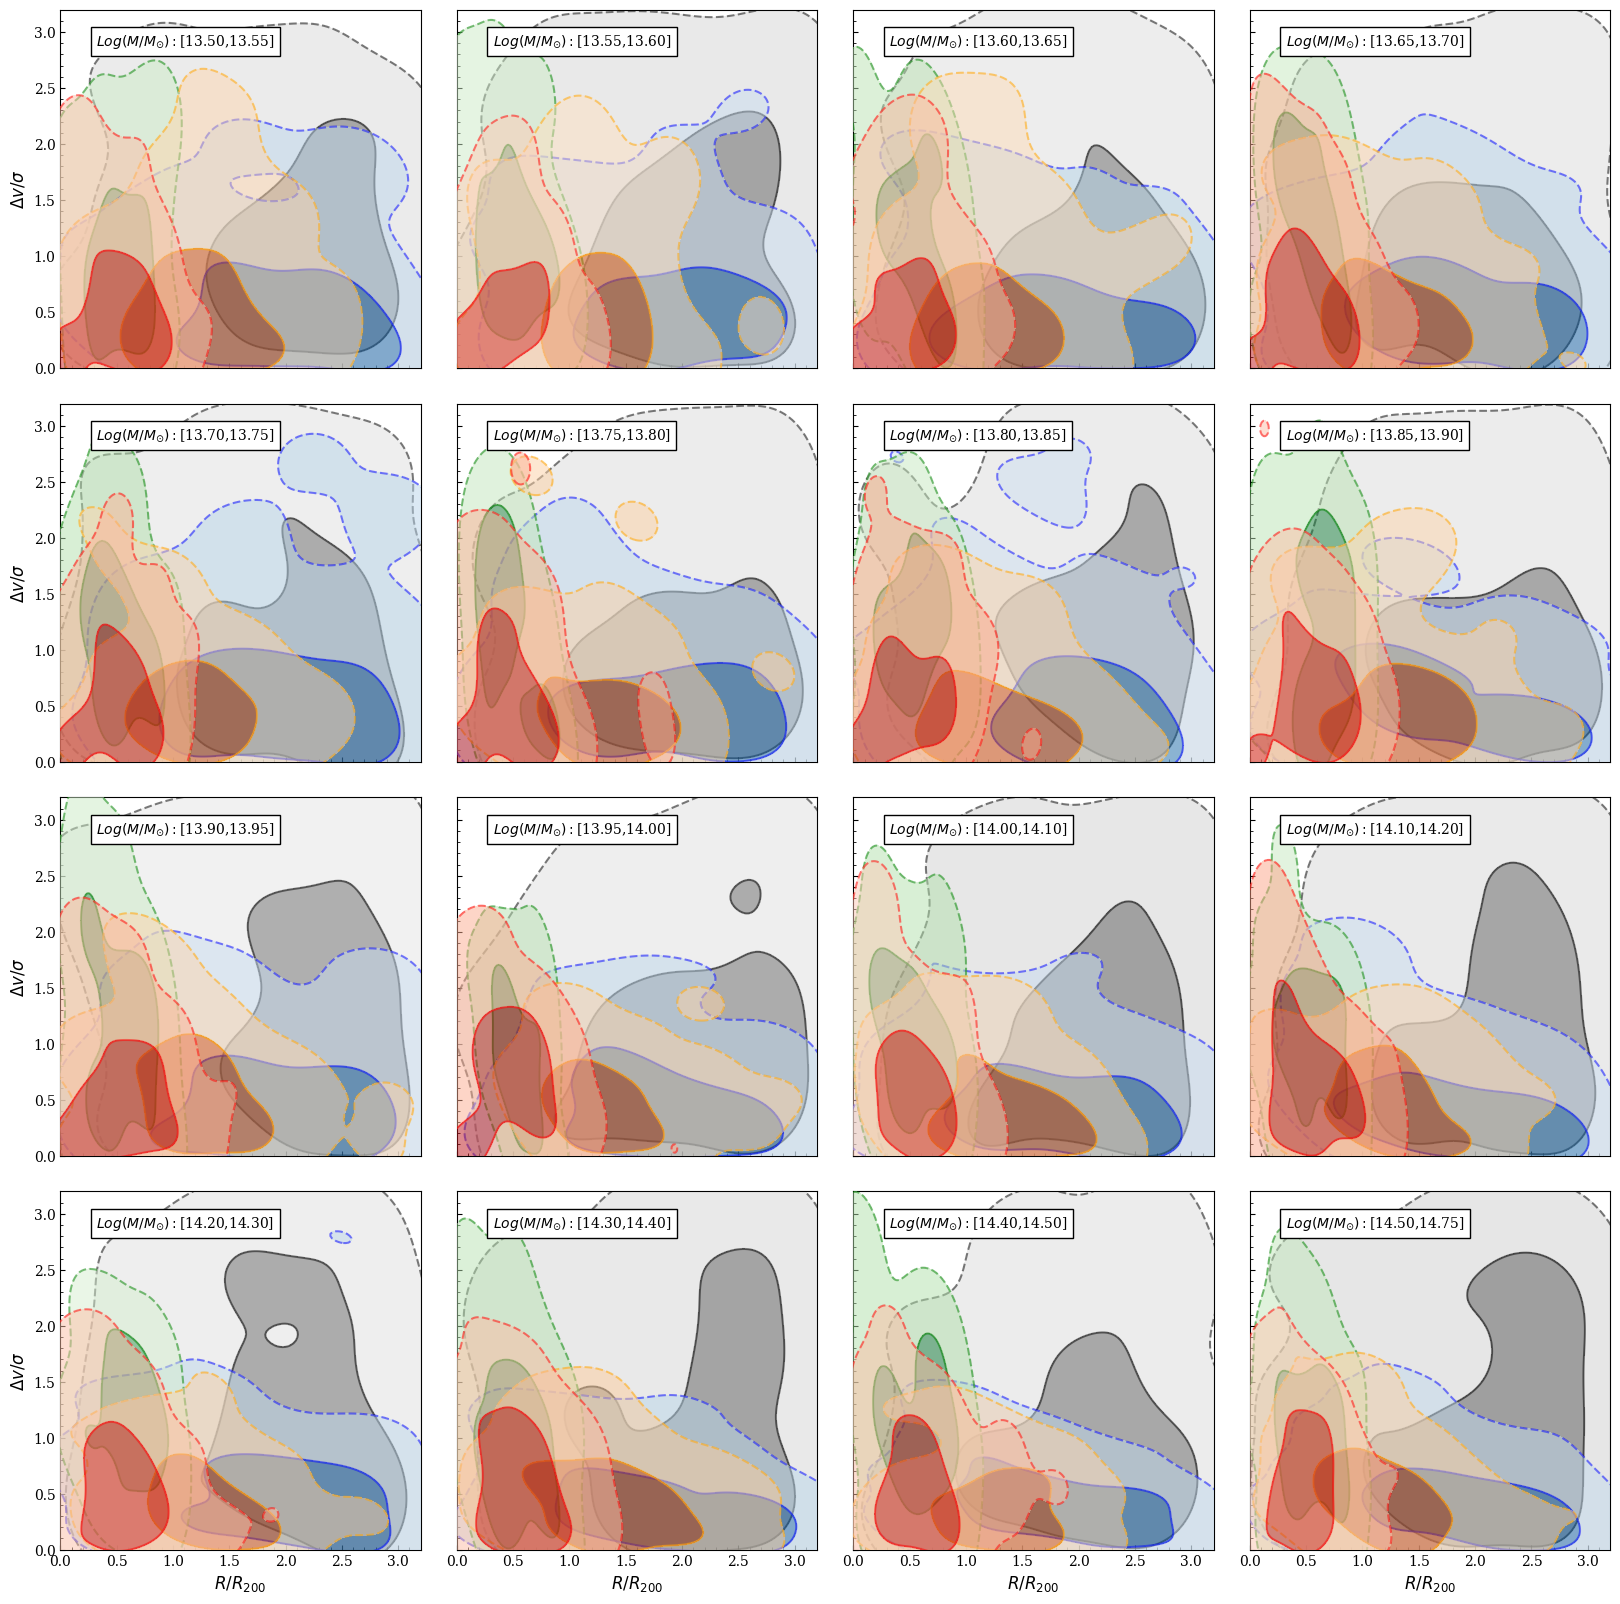

In [18]:
data_aux = data[np.random.randint(0,len(data),10000)] # Take a subsample of galaxies to make the plot faster

colors = ['red', 'orange', 'green', 'blue', 'black']
cmaps = ['Reds', 'Oranges', 'Greens', 'Blues', 'Grays']
num_bins = 20
x_bin_edges = np.linspace(0, 3, num_bins + 1)
y_bin_edges = np.linspace(0, 3, num_bins + 1)


fig,axes = plt.subplots(4,4, figsize = (20,20), sharex = True, sharey = True, gridspec_kw={'hspace':0.1, 'wspace':0.1})

for i, ax in enumerate(axes.flatten()[:]): # Loop over mass bins
  if i + 1 < len(mass_bins):
    for j in range(5): # Loop over classes
      ind = np.where( (data_aux[:,2] > mass_bins[i]) & (data_aux[:,2] < mass_bins[i+1]) & (data_aux[:,1] == (j+1)) )[0]

      sns.kdeplot(x=data_aux[ind, 3], y=data_aux[ind, 4], fill=True, alpha = 0.5, cmap=cmaps[j], levels=3, ax = ax, zorder = (6-j))
      sns.kdeplot(x=data_aux[ind, 3], y=data_aux[ind, 4], fill=False, alpha = 0.5, color=colors[j], levels=3, ax = ax, zorder = (6-j), linestyles=['--', '-', 'solid'])

    ax.text(0.1, 0.90, '$Log (M/M_{\\odot}): $' + '[{:.2f},{:.2f}]'.format(mass_bins[i], mass_bins[i+1]), transform = ax.transAxes,
            bbox=dict(facecolor='white', alpha=1, edgecolor='black'), zorder = 10)

axes[0,0].set_xlim(0,3.2)
axes[0,0].set_ylim(0,3.2)

for ax in axes[-1,:]:
  ax.set_xlabel('$R/R_{200}$', fontsize = 12)
for ax in axes[:,0]:
  ax.set_ylabel('$\\Delta v / \\sigma$', fontsize = 12)

#plt.savefig(path + 'graphs/PPSD_massbins.pdf', bbox_inches='tight')

# Fig. 1

In [19]:
mass_bins = np.linspace(13.55, 15.36, 8)

In [20]:
niter = 10

mediana_r = np.zeros((niter, 5, (len(mass_bins) -1) ))
mediana_v = np.zeros((niter, 5, (len(mass_bins) -1) ))

np.random.seed(42)

for k in range(niter):
  data_aux = data[np.random.randint(0,len(data),100000)] # Take a subsample of galaxies to make the plot faster
  for i, mass in enumerate(mass_bins): # Loop over mass bins
    if i + 1 < len(mass_bins):
      for j in range(5): # Loop over classes
        ind = np.where( (data_aux[:,2] > mass_bins[i]) & (data_aux[:,2] < mass_bins[i+1]) & (data_aux[:,1] == (j+1)) )[0]

        mediana_r[k, j,i] = np.median(data_aux[ind,3])
        mediana_v[k, j,i] = np.median(data_aux[ind,4])

<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_51876/3881585650.py:15: SyntaxWarning: invalid escape sequence '\l'
  ax[1].set_xlabel('$\log (M_{200}/h^{-1}M_{\\odot})$', fontsize = 12)


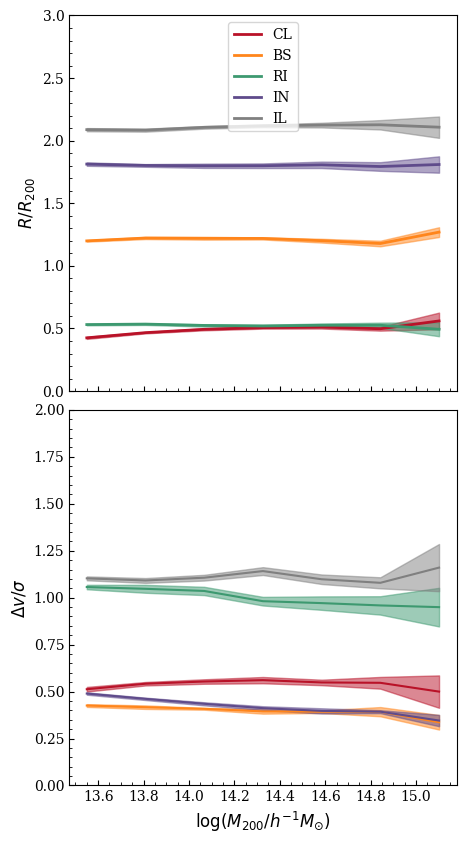

In [21]:
fig, ax = plt.subplots(2,1, sharex = True, sharey = False, figsize = (5,10), gridspec_kw={'hspace':0.05})

for i in range(5):
  ax[0].plot(mass_bins[:-1], np.mean(mediana_r, axis = 0)[i,:], label = clase[i], color = col[i], lw = 2)
  ax[0].fill_between(mass_bins[:-1], (np.mean(mediana_r, axis = 0)[i,:] - np.std(mediana_r, axis = 0)[i,:]), (np.mean(mediana_r, axis = 0)[i,:] + np.std(mediana_r, axis = 0)[i,:]),
                     color = col[i], alpha = 0.5)
  ax[1].plot(mass_bins[:-1], np.mean(mediana_v, axis = 0)[i,:], label = clase[i], color = col[i])
  ax[1].fill_between(mass_bins[:-1], (np.mean(mediana_v, axis = 0)[i,:] - np.std(mediana_v, axis = 0)[i,:]), (np.mean(mediana_v, axis = 0)[i,:] + np.std(mediana_v, axis = 0)[i,:]),
                     color = col[i], alpha = 0.5)


ax[0].set_ylim(0,3)
ax[1].set_ylim(0,2)

ax[1].set_xlabel('$\log (M_{200}/h^{-1}M_{\\odot})$', fontsize = 12)

ax[0].set_ylabel('$R/R_{200}$', fontsize = 12)
ax[1].set_ylabel('$\\Delta v / \\sigma$', fontsize = 12)

ax[0].legend()

plt.savefig(path + 'graphs/medians.pdf', bbox_inches='tight')

# Fig. 2

In [22]:
niter = 10
fraccion = np.zeros((niter, 5, (len(mass_bins) -1) ))

np.random.seed(42)

for k in range(niter):
  data_aux = data[np.random.randint(0,len(data),100000)] # Take a subsample of galaxies to make the plot faster

  for i, mass in enumerate(mass_bins): # Loop over mass bins
    if i + 1 < len(mass_bins):
      for j in range(5): # Loop over classes
        ind = np.where( (data_aux[:,2] > mass_bins[i]) & (data_aux[:,2] < mass_bins[i+1]) & (data_aux[:,1] == (j+1)) )[0]

        fraccion[k, j,i] = len(ind)

for k in range(niter): # For normalizing in each mass bin
  aux = fraccion[k,:,:]
  aux = aux / np.sum(aux, axis = 0)
  fraccion[k,:,:] = aux

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_51876/3551668862.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\log (M_{200}/h^{-1}M_{\\odot})$', fontsize = 12)


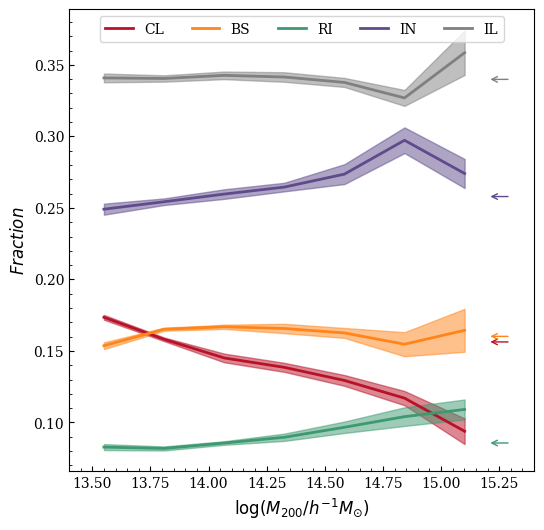

In [23]:
fig, ax = plt.subplots(1,1, sharex = True, sharey = False, figsize = (6,6), gridspec_kw={'hspace':0.05})

for i in range(5):
  ax.plot(mass_bins[:-1], np.mean(fraccion, axis = 0)[i,:], label = clase[i], color = col[i], lw = 2)
  ax.fill_between(mass_bins[:-1], (np.mean(fraccion, axis = 0)[i,:] - np.std(fraccion, axis = 0)[i,:]), (np.mean(fraccion, axis = 0)[i,:] + np.std(fraccion, axis = 0)[i,:]),
                  color = col[i], alpha = 0.5)

  ind = np.where( data_aux[:,1] == (i+1) )[0]

  base_y = len(ind)/len(data_aux)

  ax.annotate('', xy=(15.20, base_y), xytext=(15.30, base_y), arrowprops=dict(color=col[i], arrowstyle="->"),horizontalalignment='right',
              verticalalignment='center')

ax.set_xlim(13.4,15.4)

ax.set_xlabel('$\log (M_{200}/h^{-1}M_{\\odot})$', fontsize = 12)

ax.set_ylabel('$Fraction$', fontsize = 12)

ax.legend(loc='upper center', ncol=5)

plt.savefig(path + 'graphs/fractions.pdf', bbox_inches='tight')


# Fig. 3

In [24]:
tmin = 0.19
tmax = 0.99
dt = 0.02

thresholds = np.arange(tmin, tmax + 1e-6, dt)

mmin = np.array([15.00, 14.66, 14.33, 14.00, 13.50])
mmax = np.array([15.50, 15.00, 14.66, 14.33, 14.00])

icl         = testset[:,0].astype(int)
true_class  = testset[:,1].astype(int)

m200 = testset[:,2]
rp   = testset[:,3]
dv   = testset[:,4]

prob = testset[:,5:10] - pred_prob_sd

pred_class = np.argmax(prob, axis=1) + 1

pred_prob_max = np.max(prob, axis=1)

precision = np.zeros((5, 5, len(thresholds)))
recall = np.zeros((5, 5, len(thresholds)))

for iclass in range(5):

    print(f'Clase {clase[iclass]}')

    for ibin in range(5):

        print(f'  Bin de masa {ibin+1}')

        outfile = f'sp_thresh_{clase[iclass]}_{ibin+1}.dat'

        mass_mask = (
            (m200 >= mmin[ibin]) &
            (m200 <  mmax[ibin])
        )

        real = true_class[mass_mask]
        pred = pred_class[mass_mask]
        pmax = pred_prob_max[mass_mask]


        for it, t in enumerate(thresholds):

            pred_thr = pred.copy()

            mask = (pred_thr == iclass + 1) & (pmax < t)
            pred_thr[mask] = 0

            TP = np.sum((real == iclass + 1) &
                        (pred_thr == iclass + 1))

            FP = np.sum((real != iclass + 1) &
                        (pred_thr == iclass + 1))

            FN = np.sum((real == iclass + 1) &
                        (pred_thr != iclass + 1))

            if TP > 0:
              precision[iclass, ibin, it] = TP / (TP + FP)
              recall[iclass, ibin, it] = TP / (TP + FN)

Clase CL
  Bin de masa 1
  Bin de masa 2
  Bin de masa 3
  Bin de masa 4
  Bin de masa 5
Clase BS
  Bin de masa 1
  Bin de masa 2
  Bin de masa 3
  Bin de masa 4
  Bin de masa 5
Clase RI
  Bin de masa 1
  Bin de masa 2
  Bin de masa 3
  Bin de masa 4
  Bin de masa 5
Clase IN
  Bin de masa 1
  Bin de masa 2
  Bin de masa 3
  Bin de masa 4
  Bin de masa 5
Clase IL
  Bin de masa 1
  Bin de masa 2
  Bin de masa 3
  Bin de masa 4
  Bin de masa 5


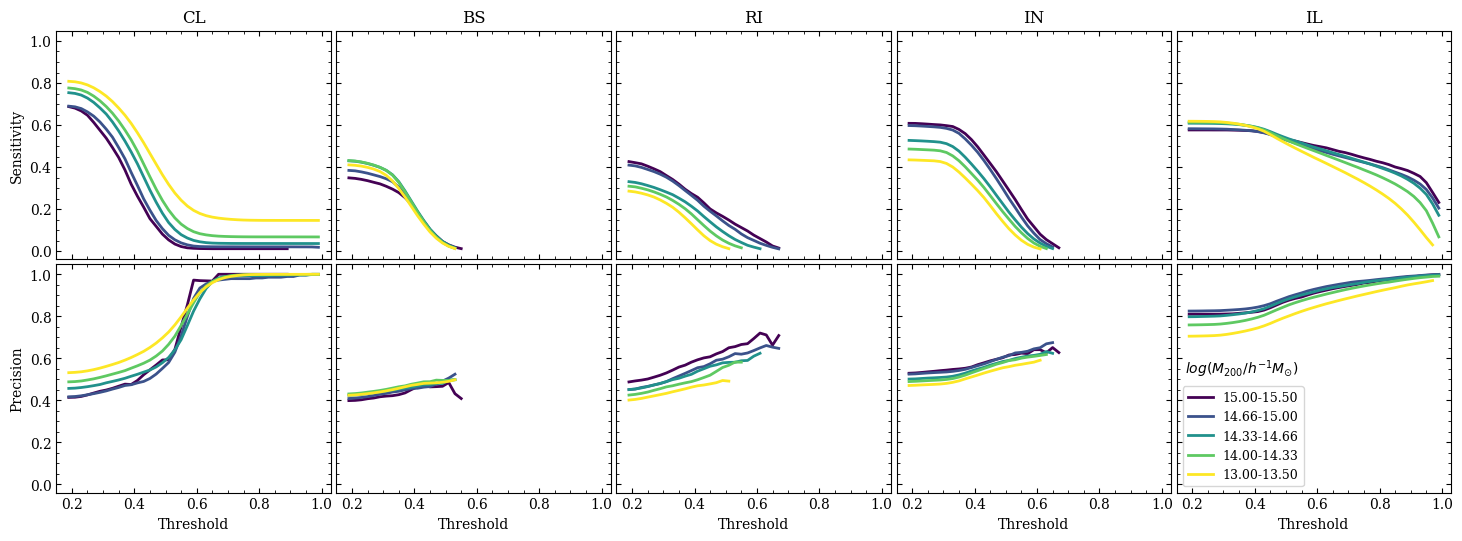

In [25]:
cmap = plt.cm.viridis
num_lines = 5
colors = cmap(np.linspace(0, 1, num_lines))

fig, ax = plt.subplots(2, 5, figsize=(18, 6), gridspec_kw={'hspace':0.02, 'wspace':0.02}, sharex = True, sharey = True)

leyenda = ['15.00-15.50', '14.66-15.00', '14.33-14.66', '14.00-14.33', '13.00-13.50']
cols_th = ['kk', 't_min','p_min','s_min']

for i in range(len(clase)):  # panel
    for j in range(len(mmin)):  # curva
        aux_ind = np.where( (recall[i, j, :] > 0.01) & (precision[i, j, :] > 0.01) )[0]
        ax[0,i].plot(thresholds[aux_ind], recall[i, j, aux_ind],
                   color=colors[j],  # <--- ahora el color depende de j
                   lw=2,#((5-j)/1.),
                   label=leyenda[j])

        #aux_ind = np.where(precision[i, j, :] > 0)[0]
        ax[1,i].plot(thresholds[aux_ind], precision[i, j, aux_ind],
                   color=colors[j],  # <--- ahora el color depende de j
                   lw=2,#((5-j)/1.),
                   label=leyenda[j])

        ax[0,i].tick_params(left = True, bottom = True, right = True, top = True, direction = 'in', which = 'both')
        ax[0,i].xaxis.set_minor_locator(AutoMinorLocator())
        ax[0,i].yaxis.set_minor_locator(AutoMinorLocator())
        ax[0,i].set_title(clase[i],loc = 'center',fontsize=12,fontfamily="serif")

        ax[1,i].set_xlabel('Threshold')
        ax[1,i].tick_params(left = True, bottom = True, right = True, top = True, direction = 'in', which = 'both')
        ax[1,i].xaxis.set_minor_locator(AutoMinorLocator())
        ax[1,i].yaxis.set_minor_locator(AutoMinorLocator())

ax[0,0].set_ylabel('Sensitivity')
ax[1,0].set_ylabel('Precision')
plt.legend(fontsize=9)
ax[1,4].text(0.03,0.52, '$log (M_{200}/h^{-1}M_{\\odot})$', transform = ax[1,4].transAxes)

plt.savefig(path + 'graphs/st.pdf', bbox_inches='tight')

# Fig. 4

-0.03943497092612801 0.17986909431625686
0.006359374292372052 0.1975688808528791
-8.55253469719388e-18 0.1899999999999999
0.029772223273026466 0.2787081717008223
-0.03815624575423236 0.26458671488272467


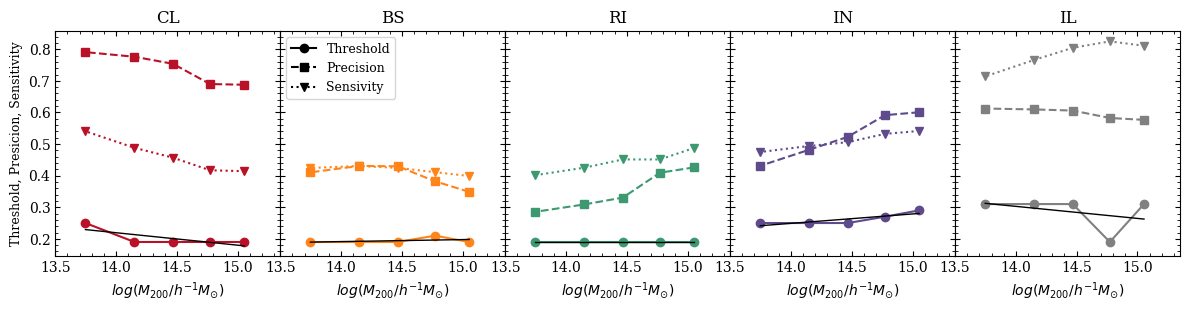

In [26]:
m_med = [15.054, 14.773, 14.468, 14.151, 13.748]
cols = ['kk', 't_min','p_min','s_min']
handles = [Line2D([0], [0],color='black',label='Threshold',linestyle='solid',lw=1.5,marker='o'),
           Line2D([0], [0],color='black',label='Precision',linestyle='dashed',lw=1.5,marker='s'),
           Line2D([0], [0],color='black',label='Sensivity',linestyle='dotted',lw=1.5,marker='v')]

aux_dist = ((1-recall)**2 + (1-precision)**2)
ind_recall0 = np.where(recall < 0.01) # Indices where recall is 0
ind_precision0 = np.where(precision < 0.01) # Indices where precision is 0
aux_dist[ind_recall0[0], ind_recall0[1], ind_recall0[2]] = 2
aux_dist[ind_precision0[0], ind_precision0[1], ind_precision0[2]] = 2

min_dist = np.min(aux_dist, axis = 2)
argmin_dist = np.argmin(aux_dist, axis = 2)

fig, ax = plt.subplots(1, 5, figsize=(12, 12), sharey = True, sharex = True, gridspec_kw = {'hspace': 0., 'wspace': 0.0})

a = np.zeros(5)
b = np.zeros(5)

for i in range(len(clase)):
    aux_recall = np.zeros(len(m_med))
    aux_precision = np.zeros(len(m_med))
    aux_threshold = np.zeros(len(m_med))
    for j in range(len(m_med)):
        aux_recall[j] = recall[i, j, argmin_dist[i,j]]
        aux_precision[j] = precision[i, j, argmin_dist[i,j]]
        aux_threshold[j] = thresholds[argmin_dist[i,j]]

    ax[i].plot(m_med, aux_recall, color = col[i],marker='s', linestyle = 'dashed')
    ax[i].plot(m_med, aux_precision, color = col[i],marker='v', linestyle='dotted')
    ax[i].plot(m_med, aux_threshold, color = col[i],marker='o')
    ax[i].set_xlim(13.5,15.35)
    ax[i].set_box_aspect(1)
    ax[i].set_xlabel(r'$log (M_{200}/h^{-1}M_{\odot})$')
    ax[0].set_ylabel('Threshold, Presicion, Sensitivity', fontsize = 9)
    ax[i].tick_params(left = True, bottom = True, right = True, top = True, direction = 'in', which = 'both')
    ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    ax[i].yaxis.set_minor_locator(AutoMinorLocator())
    ax[i].set_title(clase[i],loc = 'center',fontsize=12,fontfamily="serif")
    ax[1].legend(loc=2,handles=handles,fontsize=9)

    a[i], bb = np.polyfit(m_med, aux_threshold, 1)
    b[i] = bb+a[i]*15
    print(a[i],b[i])

    x_fit = np.linspace(min(m_med), max(m_med), 100)
    y_fit = a[i]*x_fit + bb

    ax[i].plot(x_fit, y_fit, color='black', linestyle='solid',lw=1)  # la recta ajustada
plt.tight_layout()

plt.savefig(path + 'graphs/tps.pdf', bbox_inches='tight')

# Fig. 5, 6, 7 & 8

In [27]:
def threshold(clase, logm):
    return a[clase - 1]*(logm - 15) + b[clase - 1]

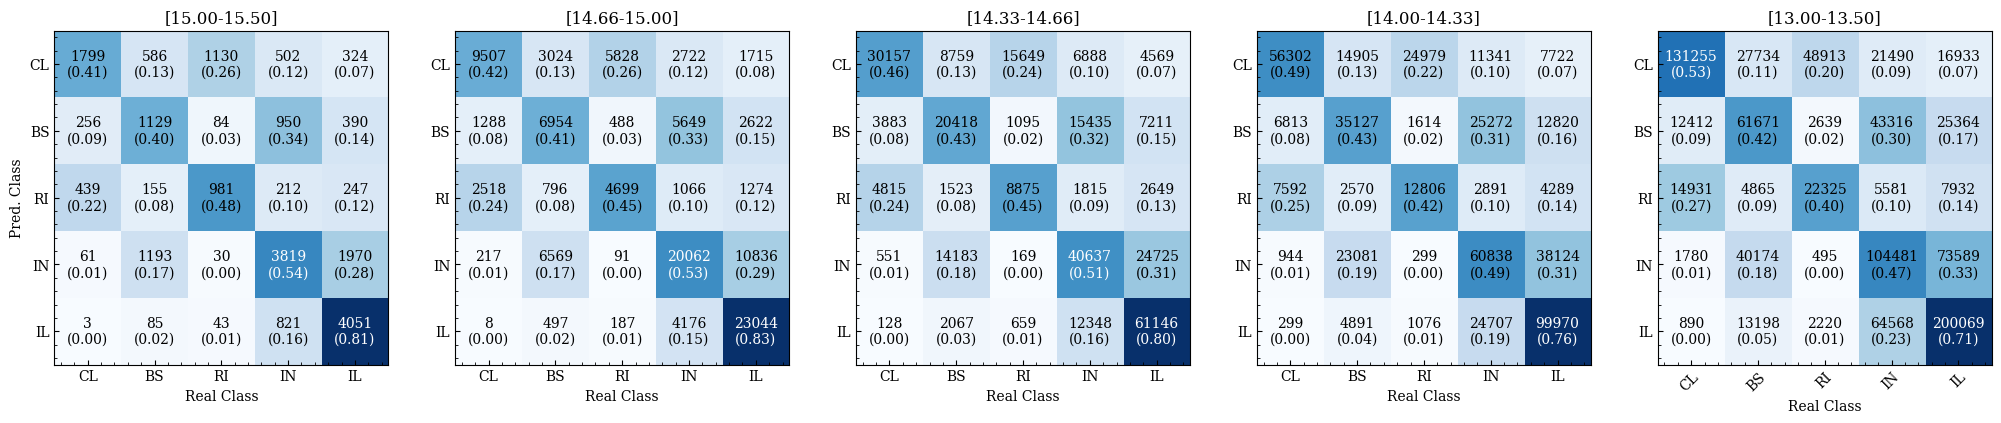

In [28]:
titles = ['[15.00-15.50]', '[14.66-15.00]', '[14.33-14.66]', '[14.00-14.33]', '[13.00-13.50]']

fig, ax = plt.subplots(1, 5, figsize=(25, 25), sharex=True, sharey=True, gridspec_kw = {'hspace': 0.1})

pred_class = np.zeros(len(testset))
for j in range(5):
  aux_ind = np.where( (testset[:,2] >= mmin[j]) &
                      (testset[:,2] <  mmax[j]) )[0]

  data_aux = testset[aux_ind]
  aux_class = np.argmax(data_aux[:,5:],axis=1) + 1 # Just the max prob

  real_class_aux = []
  pred_class_aux = []
  for i in range(len(data_aux)):
      if ( data_aux[i, (aux_class[i] + 4)] - pred_prob_sd[i, (aux_class[i] - 1)] ) >= threshold(aux_class[i], data_aux[i,2]):
          real_class_aux.append( data_aux[i,1] )
          pred_class_aux.append( aux_class[i] )
          pred_class[aux_ind[i]] = aux_class[i]


  real_class_aux = np.asarray(real_class_aux)
  pred_class_aux = np.asarray(pred_class_aux)


  conf_mat = sk.metrics.confusion_matrix(pred_class_aux, real_class_aux)
  plot_confusion_matrix(conf_mat, show_absolute=True, show_normed=True, class_names=clase, axis = ax[j])

  ax[j].set_title(titles[j])
  ax[j].set_xlabel('Real Class')
  ax[j].set_ylabel('')

ax[0].set_xlabel('Real Class')
ax[0].set_ylabel('Pred. Class')

plt.savefig(path + 'graphs/matrices_bone.pdf', bbox_inches='tight')


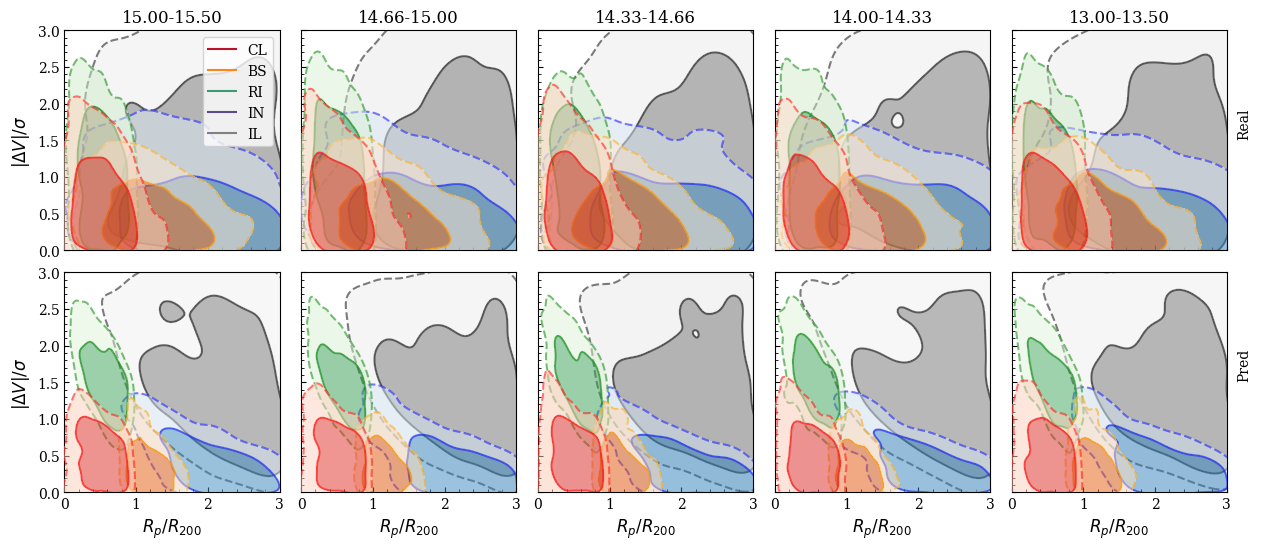

In [44]:
handles = []
for i, cl in enumerate(clase):
  handles.append(Line2D([0], [0],color=col[i],label=cl,linestyle='solid',lw=1.5))

handles2 = [Line2D([0], [0],color='black',label='$1\\sigma$',linestyle='solid',lw=1.5),
            Line2D([0], [0],color='black',label='$2\\sigma$',linestyle='dashed',lw=1.5)]
leyenda = ['15.00-15.50', '14.66-15.00', '14.33-14.66', '14.00-14.33', '13.00-13.50']

colors = ['red', 'orange', 'green', 'blue', 'black']
cmaps = ['Reds', 'Oranges', 'Greens', 'Blues', 'Grays']
num_bins = 20
x_bin_edges = np.linspace(0, 3, num_bins + 1)
y_bin_edges = np.linspace(0, 3, num_bins + 1)



fig,axes = plt.subplots(2,5, figsize = (15,6), sharex = True, sharey = True, gridspec_kw={'hspace':0.1, 'wspace':0.1})

for i, ax in enumerate(axes[0,:].flatten()[:]): # Loop over mass bins
  if i + 1 < len(mass_bins):
    for j in range(5): # Loop over classes
      #axes[0,i].set_aspect('equal', adjustable='box')
      #axes[1,i].set_aspect('equal', adjustable='box')
      aux_ind = np.where( (testset[:,2] >= mmin[j]) & (testset[:,2] <  mmax[j]) & (testset[:,1] == (j+1)) )[0]
      aux_ind = np.random.choice(aux_ind, replace = False, size = 1000)

      sns.kdeplot(x=testset[aux_ind, 3], y=testset[aux_ind, 4], fill=True, alpha = 0.5, cmap=cmaps[j], levels=[0.05,0.32,1], ax = axes[0,i], zorder = (6-j))
      sns.kdeplot(x=testset[aux_ind, 3], y=testset[aux_ind, 4], fill=False, alpha = 0.5, color=colors[j], levels=[0.05,0.32], ax = axes[0,i], zorder = (6-j), linestyles=['--', '-', 'solid'])

      aux_ind = np.where( (testset[:,2] >= mmin[j]) & (testset[:,2] <  mmax[j]) & (pred_class == (j+1)) )[0]
      aux_ind = np.random.choice(aux_ind, replace = False, size = 1000)

      sns.kdeplot(x=testset[aux_ind, 3], y=testset[aux_ind, 4], fill=True, alpha = 0.5, cmap=cmaps[j], levels=[0.05,0.32,1], ax = axes[1,i], zorder = (6-j))
      sns.kdeplot(x=testset[aux_ind, 3], y=testset[aux_ind, 4], fill=False, alpha = 0.5, color=colors[j], levels=[0.05,0.32], ax = axes[1,i], zorder = (6-j), linestyles=['--', '-', 'solid'])

axes[0,0].set_xlim(0,3.0)
axes[0,0].set_ylim(0,3.0)

for ax in axes[-1,:]:
  ax.set_xlabel(r'$R_p/R_{200}$', fontsize = 12)
for ax in axes[:,0]:
  ax.set_ylabel(r'$|\Delta V|/\sigma$', fontsize = 12)

for i, ax in enumerate(axes[0,:]):
  ax.set_title(leyenda[i],loc = 'center',fontsize=12,fontfamily="serif")

axes[0,-1].text(1.05,0.52, 'Real', transform = axes[0,-1].transAxes, rotation="vertical")
axes[0,1].text(1.05,0.52, 'Pred', transform = axes[1,-1].transAxes, rotation="vertical")

axes[0,0].legend(loc=1,handles=handles,fontsize=10)
#axes[0,1].legend(loc=1,handles=handles2,fontsize=10)

plt.savefig(path + 'graphs/distros.pdf', format='pdf', bbox_inches='tight')

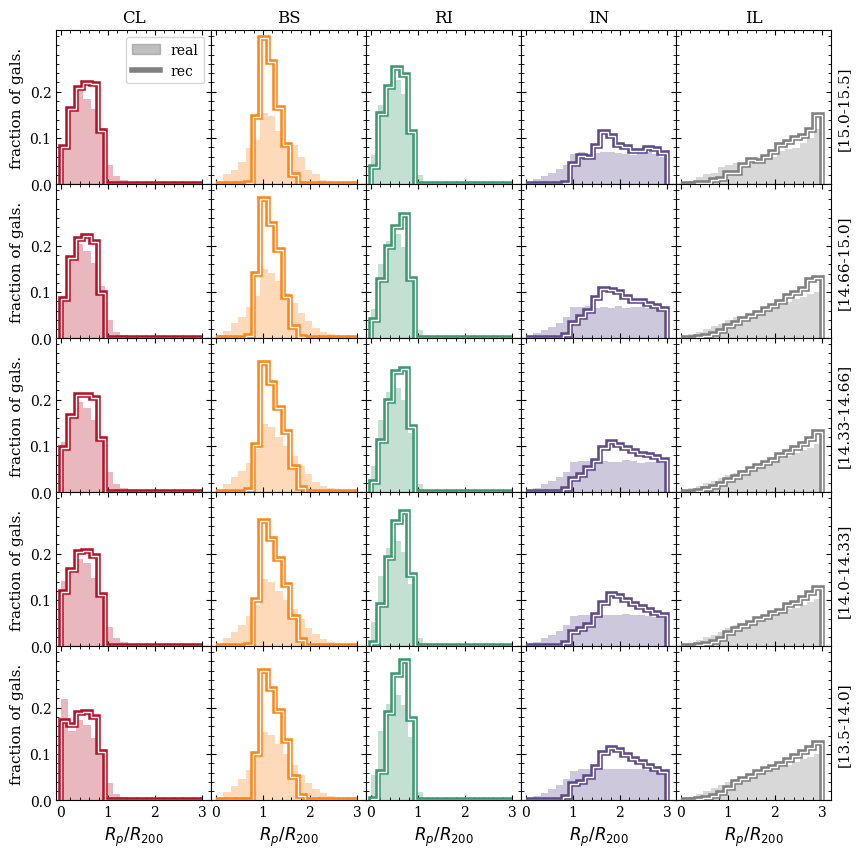

In [29]:
bins = np.linspace(0,3,20)

fig, axes = plt.subplots(5, 5, figsize=(10, 10), sharex=True, sharey=True, gridspec_kw = {'hspace': 0., 'wspace': 0.0})
handles = [mpatches.Patch(edgecolor='gray',facecolor='gray', label='real',lw=1,alpha=0.5),
           Line2D([0], [0],color='gray',label='rec',linestyle='solid',lw=4)]

for j in range(5):
    j1 = j+1
    for i in range(5):
        ax = axes[j, i]
        if (j==4):
            ax.set_xlabel(r'$R_p/R_{200}$',fontsize=12)
        if (i==0):
            ax.set_ylabel('fraction of gals.',fontsize=11)
        if (i==0 and j==0):
            ax.legend(loc=1,handles=handles,fontsize=10)
        if (j==0):
            ax.set_title(clase[i],loc = 'center',fontsize=12,fontfamily="serif")
        if (i==4):
            ax.yaxis.set_label_position("right")
            ax.set_ylabel(r'[' + str(round(mmin[j],2)) + '-' + str(round(mmax[j],2)) + ']',fontfamily="serif",fontsize=11,color="black")



        ax.set_xlim(-0.1,3.2)
        ax.tick_params(left = True, bottom = True, right = True, top = True, direction = 'in', which = 'both')
        ax.xaxis.set_ticks(np.arange(0,3.2,1))
        ax.yaxis.set_ticks(np.arange(0,0.26,0.1))
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())


        aux_ind = np.where( (testset[:,2] >= mmin[j]) &
                            (testset[:,2] <  mmax[j]) &
                            (testset[:,1] == (i+1)) )[0]
        weights = np.ones_like(testset[aux_ind,3]) / len(testset[aux_ind,3])
        ax.hist(testset[aux_ind,3], color= col[i], linestyle='-', alpha=0.3, lw=0.1, weights=weights, bins = bins, zorder = 0)

        aux_ind = np.where( (testset[:,2] >= mmin[j]) &
                            (testset[:,2] <  mmax[j]) &
                            (pred_class == (i+1)) )[0]
        weights = np.ones_like(testset[aux_ind,3]) / len(testset[aux_ind,3])
        ax.hist(testset[aux_ind,3], edgecolor= [col[i]], linestyle='-', linewidth=4, weights=weights, bins = bins, histtype = 'step')
        ax.hist(testset[aux_ind,3], edgecolor= ['white'], linestyle='-', lw=1, weights=weights, bins = bins, histtype = 'step')

plt.savefig(path + 'graphs/hist_rp_validation.pdf', format='pdf', bbox_inches='tight')

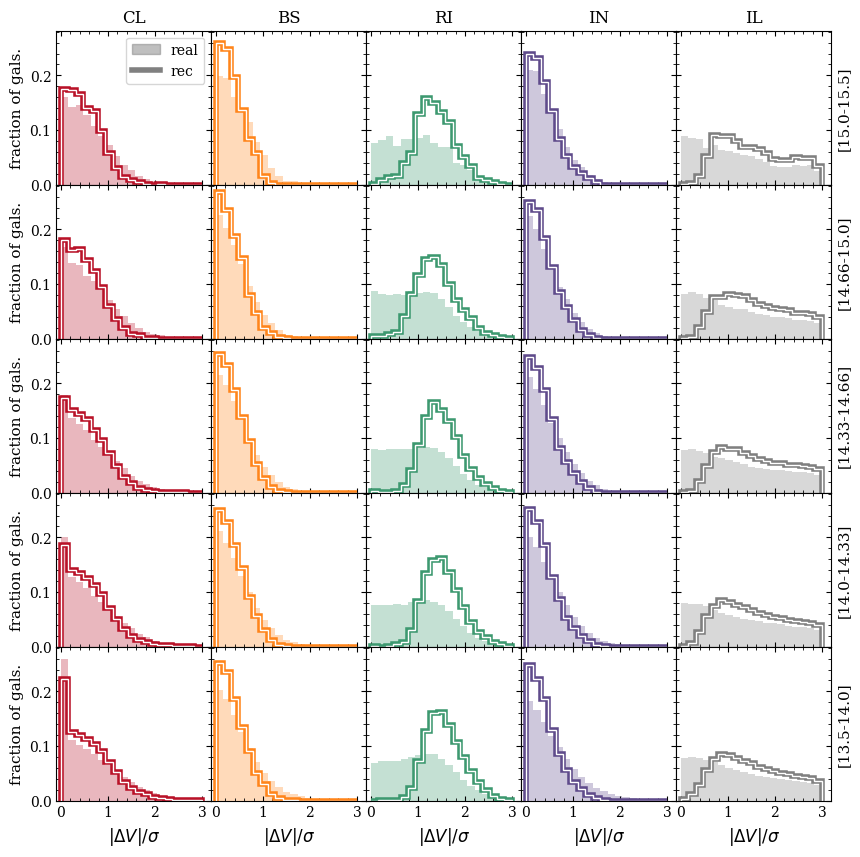

In [30]:
fig, axes = plt.subplots(5, 5, figsize=(10, 10), sharex=True, sharey=True, gridspec_kw = {'hspace': 0., 'wspace': 0.0})
handles = [mpatches.Patch(edgecolor='gray',facecolor='gray', label='real',lw=1,alpha=0.5),
           Line2D([0], [0],color='gray',label='rec',linestyle='solid',lw=4)]

for j in range(5):
    j1 = j+1
    for i in range(5):
        ax = axes[j, i]
        if (j==4):
            ax.set_xlabel(r'$|\Delta V|/\sigma$',fontsize=12)#,fontfamily="serif
        if (i==0):
            ax.set_ylabel('fraction of gals.',fontsize=11)#,fontfamily="serif
        if (i==0 and j==0):
            ax.legend(loc=1,handles=handles,fontsize=10)
        if (j==0):
            ax.set_title(clase[i],loc = 'center',fontsize=12,fontfamily="serif")
        if (i==4):
            ax.yaxis.set_label_position("right")
            ax.set_ylabel(r'[' + str(round(mmin[j],2)) + '-' + str(round(mmax[j],2)) + ']',fontfamily="serif",fontsize=11,color="black")



        ax.set_xlim(-0.1,3.2)
        ax.tick_params(left = True, bottom = True, right = True, top = True, direction = 'in', which = 'both')
        ax.xaxis.set_ticks(np.arange(0,3.2,1))
        ax.yaxis.set_ticks(np.arange(0,0.26,0.1))
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())


        aux_ind = np.where( (testset[:,2] >= mmin[j]) &
                            (testset[:,2] <  mmax[j]) &
                            (testset[:,1] == (i+1)) )[0]
        weights = np.ones_like(testset[aux_ind,4]) / len(testset[aux_ind,4])
        ax.hist(testset[aux_ind,4], color= col[i], linestyle='-', alpha=0.3, lw=0.1, weights=weights, bins = bins)

        aux_ind = np.where( (testset[:,2] >= mmin[j]) &
                            (testset[:,2] <  mmax[j]) &
                            (pred_class == (i+1)) )[0]
        weights = np.ones_like(testset[aux_ind,4]) / len(testset[aux_ind,4])
        ax.hist(testset[aux_ind,4], edgecolor= [col[i]], linestyle='-', linewidth=4, weights=weights, bins = bins, histtype = 'step')
        ax.hist(testset[aux_ind,4], edgecolor= ['white'], linestyle='-', lw=1, weights=weights, bins = bins, histtype = 'step')

plt.savefig(path + 'graphs/hist_dv_validation.pdf', format='pdf', bbox_inches='tight')